In [2]:
import pandas as pd
import numpy as np

data = pd.read_csv('aice_binary_churn_review.csv')

data.shape

(628, 15)

In [3]:
data.head()

,customer_id,age,gender,region,plan_type,contract_type,payment_method,signup_date,tenure_months,monthly_fee,support_calls,late_payments,avg_weekly_hours,auto_payment,churn
0,C100133,24.0,Male,Seoul,Basic,Monthly,Virtual account,2025-03-30,9.0,15.3,3.0,0.0,6.7,No,0
1,C100325,47.0,Male,Gwangju,Basic,Monthly,Virtual account,2024-08-29,16.0,26.4,3.0,0.0,2.2,No,1
2,C100027,53.0,Female,Daegu,Premium,One-year,Card,2025-11-04,1.0,79.3,1.0,2.0,6.8,No,0
3,C100079,22.0,Female,Busan,Premium,Two-year,Virtual account,2025-12-15,1.0,70.2,1.0,0.0,3.7,Yes,0
4,C100355,23.0,Female,Daejeon,Basic,Monthly,Card,2023-10-26,26.0,25.7,1.0,1.0,2.0,No,0


In [4]:
data.isnull().sum()

customer_id         0
age                 7
gender              5
region              7
plan_type           4
contract_type       0
payment_method      5
signup_date         4
tenure_months       0
monthly_fee         8
support_calls       6
late_payments       0
avg_weekly_hours    7
auto_payment        0
churn               0
dtype: int64

In [5]:
data.describe()

,age,tenure_months,monthly_fee,support_calls,late_payments,avg_weekly_hours,churn
count,621.000000,628.000000,620.000000,622.000000,628.000000,621.000000,628.000000
mean,39.697262,23.079618,42.069516,1.594855,0.767516,4.644605,0.127389
std,10.885110,14.365474,22.864224,1.585920,0.849108,3.413752,0.333673
min,19.000000,1.000000,3.300000,0.000000,0.000000,0.200000,0.000000
25%,32.000000,10.000000,25.200000,1.000000,0.000000,2.300000,0.000000
50%,40.000000,23.000000,40.700000,1.000000,1.000000,4.000000,0.000000
75%,46.000000,36.000000,50.000000,2.000000,1.000000,6.200000,0.000000
max,112.000000,47.000000,265.000000,21.000000,5.000000,42.000000,1.000000


In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 628 entries, 0 to 627
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       628 non-null    str    
 1   age               621 non-null    float64
 2   gender            623 non-null    str    
 3   region            621 non-null    str    
 4   plan_type         624 non-null    str    
 5   contract_type     628 non-null    str    
 6   payment_method    623 non-null    str    
 7   signup_date       624 non-null    str    
 8   tenure_months     628 non-null    float64
 9   monthly_fee       620 non-null    float64
 10  support_calls     622 non-null    float64
 11  late_payments     628 non-null    float64
 12  avg_weekly_hours  621 non-null    float64
 13  auto_payment      628 non-null    str    
 14  churn             628 non-null    int64  
dtypes: float64(6), int64(1), str(8)
memory usage: 73.7 KB


In [7]:
data.duplicated().sum()

np.int64(8)

In [8]:
print(data['churn'].value_counts())
print(data['churn'].value_counts(normalize=True))

churn
0    548
1     80
Name: count, dtype: int64
churn
0    0.872611
1    0.127389
Name: proportion, dtype: float64


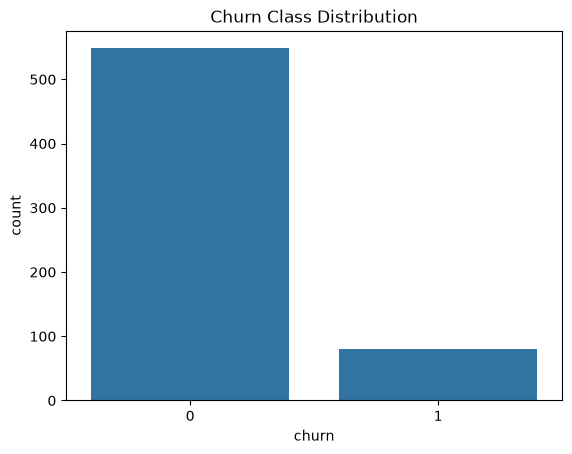

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=data, x='churn')

plt.title('Churn Class Distribution')

plt.show()
# 불균형 데이터라 strarify가 필요하다.

In [10]:
# 중복 지우기 + 인덱스 재졍렬(재정렬 하며 지워진 인덱스에 index 같은 이름 안붙이고 그냥 지워줌)
data = data.drop_duplicates().reset_index(drop=True)

In [11]:
data.shape

(620, 15)

In [12]:
data['signup_date'] = pd.to_datetime(data['signup_date'])

data['signup_year'] = data['signup_date'].dt.year
data['signup_month'] = data['signup_date'].dt.month
data['signup_day'] = data['signup_date'].dt.day
data['signup_dayofweek'] = data['signup_date'].dt.dayofweek

def median_fill(col):
    data[col] = data[col].fillna(data[col].median())

def mode_fill(col):
    data[col] = data[col].fillna(data[col].mode()[0])

data['avg_weekly_hours'] = data['avg_weekly_hours'].fillna(data['avg_weekly_hours'].mean())
mode_fill('gender')
mode_fill('region')
mode_fill('plan_type')
mode_fill('payment_method')

median_fill('age')
median_fill('monthly_fee')
median_fill('support_calls')

data = data.dropna(axis=0)
data.reset_index(drop=True, inplace=True)


In [13]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 616 entries, 0 to 615
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customer_id       616 non-null    str           
 1   age               616 non-null    float64       
 2   gender            616 non-null    str           
 3   region            616 non-null    str           
 4   plan_type         616 non-null    str           
 5   contract_type     616 non-null    str           
 6   payment_method    616 non-null    str           
 7   signup_date       616 non-null    datetime64[us]
 8   tenure_months     616 non-null    float64       
 9   monthly_fee       616 non-null    float64       
 10  support_calls     616 non-null    float64       
 11  late_payments     616 non-null    float64       
 12  avg_weekly_hours  616 non-null    float64       
 13  auto_payment      616 non-null    str           
 14  churn             616 non-null    int

In [14]:
data.isnull().sum()

customer_id         0
age                 0
gender              0
region              0
plan_type           0
contract_type       0
payment_method      0
signup_date         0
tenure_months       0
monthly_fee         0
support_calls       0
late_payments       0
avg_weekly_hours    0
auto_payment        0
churn               0
signup_year         0
signup_month        0
signup_day          0
signup_dayofweek    0
dtype: int64

In [15]:
data.duplicated().sum()

np.int64(0)

In [16]:
data['signup_date'].dtype

dtype('<M8[us]')

In [17]:

data[['signup_year', 'signup_month', 'signup_day', 'signup_dayofweek']].head()

,signup_year,signup_month,signup_day,signup_dayofweek
0,2025.0,3.0,30.0,6.0
1,2024.0,8.0,29.0,3.0
2,2025.0,11.0,4.0,1.0
3,2025.0,12.0,15.0,0.0
4,2023.0,10.0,26.0,3.0


In [18]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 616 entries, 0 to 615
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customer_id       616 non-null    str           
 1   age               616 non-null    float64       
 2   gender            616 non-null    str           
 3   region            616 non-null    str           
 4   plan_type         616 non-null    str           
 5   contract_type     616 non-null    str           
 6   payment_method    616 non-null    str           
 7   signup_date       616 non-null    datetime64[us]
 8   tenure_months     616 non-null    float64       
 9   monthly_fee       616 non-null    float64       
 10  support_calls     616 non-null    float64       
 11  late_payments     616 non-null    float64       
 12  avg_weekly_hours  616 non-null    float64       
 13  auto_payment      616 non-null    str           
 14  churn             616 non-null    int

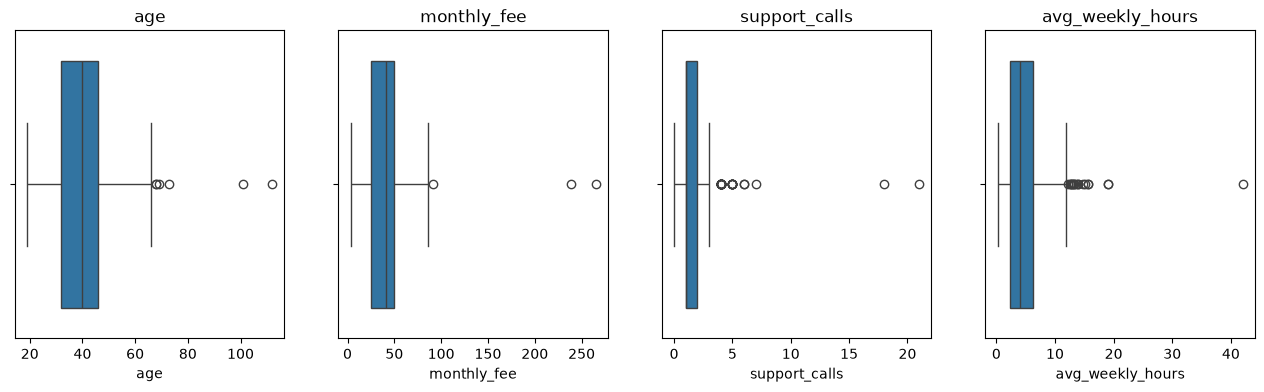

In [19]:
# 수치형 컬럼
outlier_columns = [
    'age',
    'monthly_fee',
    'support_calls',
    'avg_weekly_hours'
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

sns.boxplot(data=data, x='age', ax=axes[0])
sns.boxplot(data=data, x='monthly_fee', ax=axes[1])
sns.boxplot(data=data, x='support_calls', ax=axes[2])
sns.boxplot(data=data, x='avg_weekly_hours', ax=axes[3])

axes[0].set_title('age')
axes[1].set_title('monthly_fee')
axes[2].set_title('support_calls')
axes[3].set_title('avg_weekly_hours')

plt.show()



In [20]:
Q1 = data['monthly_fee'].quantile(0.25)
Q3 = data['monthly_fee'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR


In [21]:
# 이상치 개수
data[(data['monthly_fee']<lower)|(data['monthly_fee']>upper)].shape[0]

3

In [22]:
data_out = data.drop(data[(data['monthly_fee']<lower)|(data['monthly_fee']>upper)].index, axis=0)

In [23]:
data_out.reset_index(drop=True, inplace=True)

data_out.shape

(613, 19)

In [24]:
data_model = data_out.drop(columns=['customer_id', 'signup_date'])

In [25]:
data_model['gender'] = data_model['gender'].map({
  'Male':0,
  'Female':1
}) 

data_model['auto_payment'] = data_model['auto_payment'].map({
  'No':0,
  'Yes':1
})

In [26]:
categorical_columns = [
    'region',
    'plan_type',
    'contract_type',
    'payment_method'
]

data_model = pd.get_dummies(data_model, categorical_columns, dtype=int)

In [27]:
data_model.head()

,age,gender,tenure_months,monthly_fee,support_calls,late_payments,avg_weekly_hours,auto_payment,churn,signup_year,signup_month,signup_day,signup_dayofweek,region_Busan,region_Daegu,region_Daejeon,region_Gwangju,region_Seoul,plan_type_Basic,plan_type_Premium,plan_type_Standard,contract_type_Monthly,contract_type_One-year,contract_type_Two-year,payment_method_Bank transfer,payment_method_Card,payment_method_Mobile,payment_method_Virtual account
0,24.0,0,9.0,15.3,3.0,0.0,6.7,0,0,2025.0,3.0,30.0,6.0,0,0,0,0,1,1,0,0,1,0,0,0,0,0,1
1,47.0,0,16.0,26.4,3.0,0.0,2.2,0,1,2024.0,8.0,29.0,3.0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,1
2,53.0,1,1.0,79.3,1.0,2.0,6.8,0,0,2025.0,11.0,4.0,1.0,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0
3,22.0,1,1.0,70.2,1.0,0.0,3.7,1,0,2025.0,12.0,15.0,0.0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1
4,23.0,1,26.0,25.7,1.0,1.0,2.0,0,0,2023.0,10.0,26.0,3.0,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0


In [28]:
X = data_model.drop(columns=['churn'])
y = data_model['churn']

data_model.shape

(613, 28)

In [29]:
print(X.shape, y.shape, X.dtypes)

(613, 27) (613,) age                               float64
gender                              int64
tenure_months                     float64
monthly_fee                       float64
support_calls                     float64
late_payments                     float64
avg_weekly_hours                  float64
auto_payment                        int64
signup_year                       float64
signup_month                      float64
signup_day                        float64
signup_dayofweek                  float64
region_Busan                        int64
region_Daegu                        int64
region_Daejeon                      int64
region_Gwangju                      int64
region_Seoul                        int64
plan_type_Basic                     int64
plan_type_Premium                   int64
plan_type_Standard                  int64
contract_type_Monthly               int64
contract_type_One-year              int64
contract_type_Two-year              int64
payment_method_Ba

In [30]:
print(y.value_counts(normalize=True))
X.head()

churn
0    0.872757
1    0.127243
Name: proportion, dtype: float64


,age,gender,tenure_months,monthly_fee,support_calls,late_payments,avg_weekly_hours,auto_payment,signup_year,signup_month,signup_day,signup_dayofweek,region_Busan,region_Daegu,region_Daejeon,region_Gwangju,region_Seoul,plan_type_Basic,plan_type_Premium,plan_type_Standard,contract_type_Monthly,contract_type_One-year,contract_type_Two-year,payment_method_Bank transfer,payment_method_Card,payment_method_Mobile,payment_method_Virtual account
0,24.0,0,9.0,15.3,3.0,0.0,6.7,0,2025.0,3.0,30.0,6.0,0,0,0,0,1,1,0,0,1,0,0,0,0,0,1
1,47.0,0,16.0,26.4,3.0,0.0,2.2,0,2024.0,8.0,29.0,3.0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,1
2,53.0,1,1.0,79.3,1.0,2.0,6.8,0,2025.0,11.0,4.0,1.0,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0
3,22.0,1,1.0,70.2,1.0,0.0,3.7,1,2025.0,12.0,15.0,0.0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1
4,23.0,1,26.0,25.7,1.0,1.0,2.0,0,2023.0,10.0,26.0,3.0,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0


In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
  X,
  y,
  test_size=0.2,
  random_state=42,
  stratify=y
)

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# 테스트 데이터에 다시 fit 하면 데이터의 분포 정보가 모델링 과정에 반영되어 공정한 성능 평가가 불가능해진다.

print(X_train_scaled.shape, X_test_scaled.shape, y_train.shape, y_test.shape)

(490, 27) (123, 27) (490,) (123,)


In [33]:
# 클래스별 비율 확인
print(y_train.value_counts(normalize=True), y_test.value_counts(normalize=True))
# 첫 번째 행
print(X_train_scaled[0])

churn
0    0.873469
1    0.126531
Name: proportion, dtype: float64 churn
0    0.869919
1    0.130081
Name: proportion, dtype: float64
[ 0.21268026  0.92144268  0.71539934  0.21371381 -0.36335275 -0.8896113
 -0.72835586  0.80268007 -0.48105056 -1.0160587   1.39428152 -0.48315065
 -0.57577925 -0.39798547 -0.40824829 -0.30618622  1.26197963 -0.95998366
 -0.4417261   1.34164079 -1.24582637 -0.59463532  2.57997093  1.66410059
 -0.79924714 -0.5694948  -0.33333333]


In [34]:
# 열별 평균 중 처음 5개 
print(X_train_scaled.mean(axis=0)[:5])

# 열별 표준편차 중 처음 5개
print(X_train_scaled.std(axis=0)[:5])

[-2.53765263e-16 -1.01506105e-16 -6.52539247e-17  4.53152255e-16
 -1.17819586e-17]
[1. 1. 1. 1. 1.]


In [48]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(random_state=42)

logistic_model.fit(X_train_scaled, y_train)

y_pred = logistic_model.predict(X_test_scaled)

y_proba = logistic_model.predict_proba(X_test_scaled)[:,1]


print(y_pred[:10])
print(y_proba[:10])

[1 0 0 0 0 0 0 0 0 0]
[0.50719473 0.08996127 0.04032653 0.06661073 0.00709978 0.17929109
 0.11513435 0.04224006 0.01485745 0.11459995]


In [51]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.metrics import recall_score, precision_score, f1_score

# 혼동행렬
print(confusion_matrix(y_test, y_pred))
# 정확도
print(accuracy_score(y_test, y_pred))
# 재현율
print(recall_score(y_test, y_pred))
# 정밀도
print(precision_score(y_test, y_pred))
# f1-score
print(f1_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

[[103   4]
 [ 15   1]]
0.8455284552845529
0.0625
0.2
0.09523809523809523
              precision    recall  f1-score   support

           0       0.87      0.96      0.92       107
           1       0.20      0.06      0.10        16

    accuracy                           0.85       123
   macro avg       0.54      0.51      0.51       123
weighted avg       0.79      0.85      0.81       123



In [57]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, y_proba)
y_pred_03 = (y_proba >= 0.3).astype(int)

# 혼동행렬
print(confusion_matrix(y_test, y_pred_03))

# 정확도
print(accuracy_score(y_test, y_pred_03))

# 재현율
print(recall_score(y_test, y_pred_03))

# 정밀도
print(precision_score(y_test, y_pred_03))

# f1-score
print(f1_score(y_test, y_pred_03))


[[100   7]
 [ 12   4]]
0.8455284552845529
0.25
0.36363636363636365
0.2962962962962963


In [59]:
model_bal = LogisticRegression(
  random_state=42,
  class_weight='balanced'
)

model_bal.fit(
  X_train_scaled,
  y_train
);

In [63]:
y_pred_balanced = model_bal.predict(X_test_scaled)
y_proba_balanced = model_bal.predict_proba(X_test_scaled)[:,1]

# 혼동행렬
print(confusion_matrix(y_test, y_pred_balanced))

# 정확도
print(accuracy_score(y_test, y_pred_balanced))

# 재현율
print(recall_score(y_test, y_pred_balanced))

# 정밀도
print(precision_score(y_test, y_pred_balanced))

# f1-score
print(f1_score(y_test, y_pred_balanced))

# roc-auc - proba 넣어야함
print(roc_auc_score(y_test, y_proba_balanced))

print(classification_report(y_test, y_pred_balanced))


[[78 29]
 [ 5 11]]
0.7235772357723578
0.6875
0.275
0.39285714285714285
0.7727803738317757
              precision    recall  f1-score   support

           0       0.94      0.73      0.82       107
           1       0.28      0.69      0.39        16

    accuracy                           0.72       123
   macro avg       0.61      0.71      0.61       123
weighted avg       0.85      0.72      0.77       123



In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

tree_model = DecisionTreeClassifier(
  random_state=42,
  class_weight='balanced',
  max_depth=5
)

forest_model = RandomForestClassifier(
  random_state=42,
  class_weight='balanced',
  n_estimators=100,
  max_depth=5
)

In [68]:
tree_model.fit(X_train, y_train)
forest_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)
y_pred_forest = forest_model.predict(X_test)

# 혼동행렬
print(confusion_matrix(y_test, y_pred_tree))

# 정확도
print(accuracy_score(y_test, y_pred_tree))

# 재현율
print(recall_score(y_test, y_pred_tree))

# 정밀도
print(precision_score(y_test, y_pred_tree))

# f1-score
print(f1_score(y_test, y_pred_tree))

print(classification_report(y_test, y_pred_tree))


[[81 26]
 [ 8  8]]
0.7235772357723578
0.5
0.23529411764705882
0.32
              precision    recall  f1-score   support

           0       0.91      0.76      0.83       107
           1       0.24      0.50      0.32        16

    accuracy                           0.72       123
   macro avg       0.57      0.63      0.57       123
weighted avg       0.82      0.72      0.76       123



In [69]:
# 혼동행렬
print(confusion_matrix(y_test, y_pred_forest))

# 정확도
print(accuracy_score(y_test, y_pred_forest))

# 재현율
print(recall_score(y_test, y_pred_forest))

# 정밀도
print(precision_score(y_test, y_pred_forest))

# f1-score
print(f1_score(y_test, y_pred_forest))

print(classification_report(y_test, y_pred_forest))


[[91 16]
 [ 9  7]]
0.7967479674796748
0.4375
0.30434782608695654
0.358974358974359
              precision    recall  f1-score   support

           0       0.91      0.85      0.88       107
           1       0.30      0.44      0.36        16

    accuracy                           0.80       123
   macro avg       0.61      0.64      0.62       123
weighted avg       0.83      0.80      0.81       123



In [72]:
from sklearn.model_selection import cross_val_score

lr_score = cross_val_score(
  model_bal,
  X_train_scaled,
  y_train,
  cv=5,
  scoring='recall' 
)

dt_score = cross_val_score(
  tree_model,
  X_train,
  y_train,
  cv=5,
  scoring='recall'
)

rf_score = cross_val_score(
  forest_model,
  X_train,
  y_train,
  cv=5,
  scoring='recall'
)

print('lr : ', lr_score)
print('dt : ', dt_score)
print('rf : ', rf_score)

print('lr : ', lr_score.mean())
print('dt : ', dt_score.mean())
print('rf : ', rf_score.mean())


lr :  [0.66666667 0.5        0.58333333 0.61538462 0.61538462]
dt :  [0.5        0.33333333 0.25       0.30769231 0.30769231]
rf :  [0.41666667 0.25       0.16666667 0.46153846 0.23076923]
lr :  0.5961538461538461
dt :  0.33974358974358976
rf :  0.30512820512820515


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

binary_model = Sequential([
  Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
  Dropout(0.2),
  Dense(32, activation='relu'),
  Dense(1, activation='sigmoid')
])

# 회귀 = linear
# 이진 분류 = sigmoid
# 다중 분류 = softmax

binary_model.compile(
  optimizer='adam',
  loss='binary_crossentropy',
  metrics=['accuracy']
)

c:\Users\kom73\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

estop = EarlyStopping(
  monitor='val_loss',
  patience=10,
  restore_best_weights=True
)

checkpoint = ModelCheckpoint(
  filepath='best_binary_model.keras',
  monitor='val_loss',
  save_best_only=True
)

history = binary_model.fit(
  X_train_scaled,
  y_train,
  validation_split=0.2, # val_loss 가 생김
  epochs=100,
  batch_size=32,
  callbacks=[estop, checkpoint]
)


Epoch 1/100


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8776 - loss: 0.2792 - val_accuracy: 0.9286 - val_loss: 0.2164
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8852 - loss: 0.2787 - val_accuracy: 0.9184 - val_loss: 0.2247
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8852 - loss: 0.2720 - val_accuracy: 0.9082 - val_loss: 0.2223
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8852 - loss: 0.2640 - val_accuracy: 0.8980 - val_loss: 0.2245
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8801 - loss: 0.2810 - val_accuracy: 0.8980 - val_loss: 0.2273
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8980 - loss: 0.2587 - val_accuracy: 0.9082 - val_loss: 0.2355
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8878 - loss: 0.2475 - val_accuracy: 0.9082 - val_loss: 0.2361
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8980 - loss: 0.2466 - val_accuracy: 0.8980 - val_loss: 0.2

In [93]:
binary_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,717 (45.77 KB)

 Trainable params: 3,905 (15.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,812 (30.52 KB)

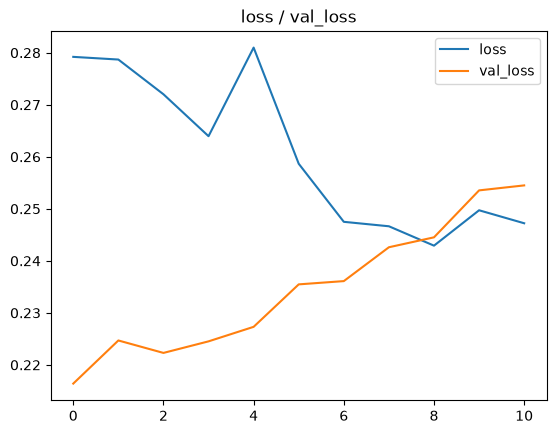

In [94]:
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')

plt.title('loss / val_loss')
plt.legend()

plt.show()

In [95]:
# 실제로 실행된 epoch마다 loss가 하나씩 저장되므로 길이를 세면 된다.
print(len(history.history['loss']))
print(len(history.epoch))

11
11


In [ ]:
test_loss, test_accuracy = binary_model.evaluate(
  X_test_scaled,
  y_test
)

print('loss : ', test_loss) # 손실값
print('accuracy : ', test_accuracy) # 정확도 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8537 - loss: 0.3152 
loss :  0.31522658467292786
accuracy :  0.8536585569381714


In [ ]:
# 예측 확률
# (123, 1) -> (123,) 으로 만들어줌
y_proba_dl = binary_model.predict(X_test_scaled).ravel()
y_proba_dl

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


array([0.5427995 , 0.20614813, 0.02066131, 0.06959348, 0.02842126,
       0.19823962, 0.19527571, 0.01565247, 0.01606241, 0.1703357 ,
       0.01636008, 0.00933164, 0.16895245, 0.06552083, 0.0471448 ,
       0.00779623, 0.18428384, 0.18171436, 0.3844207 , 0.0227755 ,
       0.39994445, 0.10782842, 0.10291486, 0.07000516, 0.13631554,
       0.0185071 , 0.12331327, 0.10815225, 0.07160446, 0.02366408,
       0.00890045, 0.08618867, 0.17882922, 0.03333975, 0.2797082 ,
       0.01079514, 0.14552633, 0.04758301, 0.08386696, 0.03016922,
       0.09984668, 0.05833975, 0.48431915, 0.05160844, 0.48227516,
       0.17868507, 0.25513896, 0.08900723, 0.06806807, 0.0274659 ,
       0.03773253, 0.03603553, 0.2018373 , 0.02241524, 0.1582388 ,
       0.03594621, 0.03028469, 0.4479824 , 0.00470667, 0.04909931,
       0.22227848, 0.0864605 , 0.02561313, 0.5220939 , 0.05929399,
       0.31349814, 0.1043561 , 0.14061345, 0.06207406, 0.11417237,
       0.22879283, 0.23895212, 0.0088388 , 0.04838796, 0.02749

In [107]:
y_pred_dl_05 = (y_proba_dl>=0.5).astype(int)
y_pred_dl_03 = (y_proba_dl>=0.3).astype(int)

print(confusion_matrix(y_test, y_pred_dl_03))
print(confusion_matrix(y_test, y_pred_dl_05))

print(recall_score(y_test, y_pred_dl_03))
print(recall_score(y_test, y_pred_dl_05))

print(classification_report(y_test, y_pred_dl_03))
print(classification_report(y_test, y_pred_dl_05))

print(precision_score(y_test, y_pred_dl_03))
print(precision_score(y_test, y_pred_dl_05))
print(roc_auc_score(y_test, y_proba_dl)) 
# roc_auc_score = proba - 확률 

[[100   7]
 [ 11   5]]
[[104   3]
 [ 15   1]]
0.3125
0.0625
              precision    recall  f1-score   support

           0       0.90      0.93      0.92       107
           1       0.42      0.31      0.36        16

    accuracy                           0.85       123
   macro avg       0.66      0.62      0.64       123
weighted avg       0.84      0.85      0.84       123

              precision    recall  f1-score   support

           0       0.87      0.97      0.92       107
           1       0.25      0.06      0.10        16

    accuracy                           0.85       123
   macro avg       0.56      0.52      0.51       123
weighted avg       0.79      0.85      0.81       123

0.4166666666666667
0.25
0.8130841121495327
